<div style="
background-color:#F3E5F5;
padding:25px;
border-radius:10px;
border:2px solid #9C27B0;
text-align:center;
">

<h1 style="margin:0; color:#6A1B9A;">
 Resume Screening & Job Category Prediction
</h1>

<h2 style="margin:12px 0 5px; color:#7B1FA2;">
Future Interns – Machine Learning Internship
</h2>

<h3 style="margin:0; color:#8E24AA;">
Resume Classification using NLP and Machine Learning
</h3>

</div>


### Objective: 
To develop a Machine Learning system that automatically classifies resumes into suitable professional job categories using Natural Language Processing (NLP).

### Dataset: 
Resume Dataset – Kaggle

## Techniques: 
NLP, TF-IDF, Machine Learning, Data Visualization

### Models:
Logistic Regression, Linear SVM, Multinomial Naive Bayes

##  Project Overview

Recruiters often receive a large number of resumes for different job roles. 
Manually screening and categorizing every resume can be time-consuming.

This project uses Natural Language Processing and Machine Learning to analyze 
resume text and automatically predict the most suitable professional category.

### Workflow

Resume Data
↓
Data Cleaning
↓
Exploratory Data Analysis
↓
NLP Text Preprocessing
↓
TF-IDF Feature Extraction
↓
Machine Learning Models
↓
Model Comparison
↓
Best Model Selection
↓
Resume Category Prediction

## 🎯 Problem Statement

The goal of this project is to build an automated resume classification system 
that can categorize resumes into different professional domains.

The system should:

- Clean and preprocess resume text.
- Extract meaningful textual features.
- Train multiple Machine Learning models.
- Compare model performance.
- Select the best-performing model.
- Predict the category of a new resume.

## 🛠️ Technologies & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Regular Expressions
- Scikit-learn
- Natural Language Processing (NLP)
- TF-IDF Vectorization

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [13]:
folder_path = r"C:\Users\shaik\Downloads\archive (7)"

print(folder_path)

C:\Users\shaik\Downloads\archive (7)


In [14]:
import os

folder_path = r"C:\Users\shaik\Downloads\archive (7)"

if os.path.exists(folder_path):
    print("✅ Folder path is correct!")
else:
    print("❌ Folder path not found!")

✅ Folder path is correct!


In [27]:
import pandas as pd

path = r"C:\Users\shaik\Downloads\archive (8)\monster_com-job_sample.csv"

df = pd.read_csv(path)

print("✅ Dataset loaded successfully!")


✅ Dataset loaded successfully!


In [29]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (22000, 14)


,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
0,United States of America,US,NaN,No,jobs.monster.com,TeamSoft is seeing an IT Support Specialist to...,IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702",NaN,http://jobview.monster.com/it-support-technici...,NaN,IT/Software Development,11d599f229a80023d2f40e7c52cd941e
1,United States of America,US,NaN,No,jobs.monster.com,The Wisconsin State Journal is seeking a flexi...,Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-e...,NaN,NaN,e4cbb126dabf22159aff90223243ff2a
2,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job DePuy Synthes Co...,Johnson & Johnson Family of Companies Job Appl...,"Full Time, Employee",DePuy Synthes Companies is a member of Johnson...,Personal and Household Services,http://jobview.monster.com/senior-training-lea...,NaN,NaN,839106b353877fa3d896ffb9c1fe01c0
3,United States of America,US,NaN,No,jobs.monster.com,Why Join Altec? If you’re considering a career...,Engineer - Quality Job in Dixon,Full Time,"Dixon, CA",Altec Industries,http://jobview.monster.com/engineer-quality-jo...,NaN,Experienced (Non-Manager),58435fcab804439efdcaa7ecca0fd783
4,United States of America,US,NaN,No,jobs.monster.com,Position ID# 76162 # Positions 1 State CT C...,Shift Supervisor - Part-Time Job in Camphill,Full Time Employee,"Camphill, PA",Retail,http://jobview.monster.com/shift-supervisor-pa...,NaN,Project/Program Management,64d0272dc8496abfd9523a8df63c184c


In [30]:
df.tail()

,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
21995,United States of America,US,NaN,No,jobs.monster.com,This is a major premier Cincinnati based finan...,Assistant Vice President - Controller Job in C...,Full Time,"Cincinnati, OH",NaN,http://jobview.monster.com/Assistant-Vice-Pres...,"120,000.00 - 160,000.00 $ /yearbonus",NaN,a80bc8cc3a90c17eef418963803bc640
21996,United States of America,US,NaN,No,jobs.monster.com,Luxury homebuilder in Cincinnati seeking multi...,Accountant Job in Cincinnati,Full Time,"Cincinnati, OH 45236",Construction - Residential & Commercial/Office,http://jobview.monster.com/Accountant-Job-Cinc...,"45,000.00 - 60,000.00 $ /year",Manager (Manager/Supervisor of Staff),419a3714be2b30a10f628de207d041de
21997,United States of America,US,NaN,No,jobs.monster.com,RE: Adobe AEM- Client - Loca...,AEM/CQ developer Job in Chicago,Full Time,"Chicago, IL 60602",NaN,http://jobview.monster.com/AEM-CQ5-developer-J...,NaN,NaN,5a590350b73b2cec46b05750a208e345
21998,United States of America,US,NaN,No,jobs.monster.com,Jernberg Industries was established in 1937 an...,Electrician - Experienced Forging Electrician ...,Full Time Employee,"Chicago, IL 60609","Jernberg Industries, Inc.",http://jobview.monster.com/Electrician-Experie...,25.00 - 28.00 $ /hour,Installation/Maintenance/Repair,40161cf61c283af9dc2b0a62947a5f1b
21999,United States of America,US,NaN,No,jobs.monster.com,Contract AdministratorCan you be the point per...,Contract Administrator Job in Cincinnati,Full Time,"Cincinnati, OH",NaN,http://jobview.monster.com/Contract-Administra...,"40,000.00 - 46,000.00 $ /year+ annual bonus (u...",Experienced (Non-Manager),cb49f16ad72627b109e434e0cac97f7a


In [31]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 22000
Number of Columns: 14


In [32]:
print("Dataset Columns:")
for column in df.columns:
    print("-", column)

Dataset Columns:
- country
- country_code
- date_added
- has_expired
- job_board
- job_description
- job_title
- job_type
- location
- organization
- page_url
- salary
- sector
- uniq_id


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   country          22000 non-null  str  
 1   country_code     22000 non-null  str  
 2   date_added       122 non-null    str  
 3   has_expired      22000 non-null  str  
 4   job_board        22000 non-null  str  
 5   job_description  22000 non-null  str  
 6   job_title        22000 non-null  str  
 7   job_type         20372 non-null  str  
 8   location         22000 non-null  str  
 9   organization     15133 non-null  str  
 10  page_url         22000 non-null  str  
 11  salary           3446 non-null   str  
 12  sector           16806 non-null  str  
 13  uniq_id          22000 non-null  str  
dtypes: str(14)
memory usage: 67.1 MB


In [34]:
df.describe(include="all")

,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
count,22000,22000,122,22000,22000,22000,22000,20372,22000,15133,22000,3446,16806,22000
unique,1,1,78,1,1,18744,18759,39,8423,738,22000,1737,163,22000
top,United States of America,US,9/22/2016,No,jobs.monster.com,12N Horizontal Construction Engineers Job Desc...,Monster,Full Time,"Dallas, TX",Healthcare Services,http://jobview.monster.com/it-support-technici...,"40,000.00 - 100,000.00 $ /year",Experienced (Non-Manager),11d599f229a80023d2f40e7c52cd941e
freq,22000,22000,6,22000,22000,104,318,6757,646,1919,1,50,4594,1


In [35]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
country                0
country_code           0
date_added         21878
has_expired            0
job_board              0
job_description        0
job_title              0
job_type            1628
location               0
organization        6867
page_url               0
salary             18554
sector              5194
uniq_id                0
dtype: int64


In [36]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [38]:
# CELL 15 — Safe Data Cleaning

# Remove duplicate rows
df = df.drop_duplicates()

# Remove completely empty rows
df = df.dropna(how="all")

# Reset index
df = df.reset_index(drop=True)

print("✅ Data cleaning completed successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

✅ Data cleaning completed successfully!
Rows: 22000
Columns: 14

Column Names:
['country', 'country_code', 'date_added', 'has_expired', 'job_board', 'job_description', 'job_title', 'job_type', 'location', 'organization', 'page_url', 'salary', 'sector', 'uniq_id']

Missing Values:
country                0
country_code           0
date_added         21878
has_expired            0
job_board              0
job_description        0
job_title              0
job_type            1628
location               0
organization        6867
page_url               0
salary             18554
sector              5194
uniq_id                0
dtype: int64


In [44]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 22000
Number of columns: 14

Column names:
['country', 'country_code', 'date_added', 'has_expired', 'job_board', 'job_description', 'job_title', 'job_type', 'location', 'organization', 'page_url', 'salary', 'sector', 'uniq_id']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   country          22000 non-null  str  
 1   country_code     22000 non-null  str  
 2   date_added       122 non-null    str  
 3   has_expired      22000 non-null  str  
 4   job_board        22000 non-null  str  
 5   job_description  22000 non-null  str  
 6   job_title        22000 non-null  str  
 7   job_type         20372 non-null  str  
 8   location         22000 non-null  str  
 9   organization     15133 non-null  str  
 10  page_url         22000 non-null  str  
 11  salary           3446 non-null   str  
 12  sector         

In [45]:
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("✅ Clean column names:")
print(df.columns.tolist())

✅ Clean column names:
['country', 'country_code', 'date_added', 'has_expired', 'job_board', 'job_description', 'job_title', 'job_type', 'location', 'organization', 'page_url', 'salary', 'sector', 'uniq_id']


In [46]:
print("Available columns:")
print(df.columns.tolist())

resume_candidates = [
    "resume",
    "resume_text",
    "text",
    "description",
    "cv",
    "cv_text"
]

category_candidates = [
    "category",
    "job_category",
    "job_role",
    "role",
    "label",
    "class"
]

resume_col = None
category_col = None

for col in resume_candidates:
    if col in df.columns:
        resume_col = col
        break

for col in category_candidates:
    if col in df.columns:
        category_col = col
        break

print("\nResume column:", resume_col)
print("Category column:", category_col)

Available columns:
['country', 'country_code', 'date_added', 'has_expired', 'job_board', 'job_description', 'job_title', 'job_type', 'location', 'organization', 'page_url', 'salary', 'sector', 'uniq_id']

Resume column: None
Category column: None


In [47]:
if resume_col is None:
    object_columns = df.select_dtypes(
        include="object"
    ).columns.tolist()
    
    resume_col = max(
        object_columns,
        key=lambda col: df[col].astype(str).str.len().mean()
    )

if category_col is None:
    remaining_columns = [
        col for col in df.columns
        if col != resume_col
    ]
    
    category_col = remaining_columns[0]

df["resume_text"] = (
    df[resume_col]
    .fillna("")
    .astype(str)
)

df["category"] = (
    df[category_col]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

print("✅ Dataset prepared!")
print("Resume column:", resume_col)
print("Category column:", category_col)

✅ Dataset prepared!
Resume column: job_description
Category column: country


In [48]:
print("Missing values:")

display(
    df[["resume_text", "category"]]
    .isnull()
    .sum()
)

df["resume_text"] = df["resume_text"].fillna("")
df["category"] = df["category"].fillna("Unknown")

print("\n✅ Missing values handled!")

Missing values:


resume_text    0
category       0
dtype: int64


✅ Missing values handled!


In [49]:
before = len(df)

df = df.drop_duplicates(
    subset=["resume_text"]
).reset_index(drop=True)

after = len(df)

print("Duplicates removed:", before - after)
print("Remaining resumes:", after)

Duplicates removed: 3256
Remaining resumes: 18744


### Text Cleaning

In [50]:
def clean_text(text):
    text = str(text).lower()
    
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )
    
    text = re.sub(
        r"\S+@\S+",
        " ",
        text
    )
    
    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )
    
    text = re.sub(
        r"\s+",
        " ",
        text
    )
    
    return text.strip()


df["clean_resume"] = (
    df["resume_text"]
    .apply(clean_text)
)

print("✅ Resume text cleaned!")

✅ Resume text cleaned!


### Before vs After Cleaning

In [51]:
display(
    df[
        ["resume_text", "clean_resume"]
    ].head(5)
)

,resume_text,clean_resume
0,TeamSoft is seeing an IT Support Specialist to...,teamsoft is seeing an it support specialist to...
1,The Wisconsin State Journal is seeking a flexi...,the wisconsin state journal is seeking a flexi...
2,Report this job About the Job DePuy Synthes Co...,report this job about the job depuy synthes co...
3,Why Join Altec? If you’re considering a career...,why join altec if you re considering a career ...
4,Position ID# 76162 # Positions 1 State CT C...,position id 76162 positions 1 state ct city fa...


## Resume Category Distribution

category
United States of America    18744
Name: count, dtype: int64


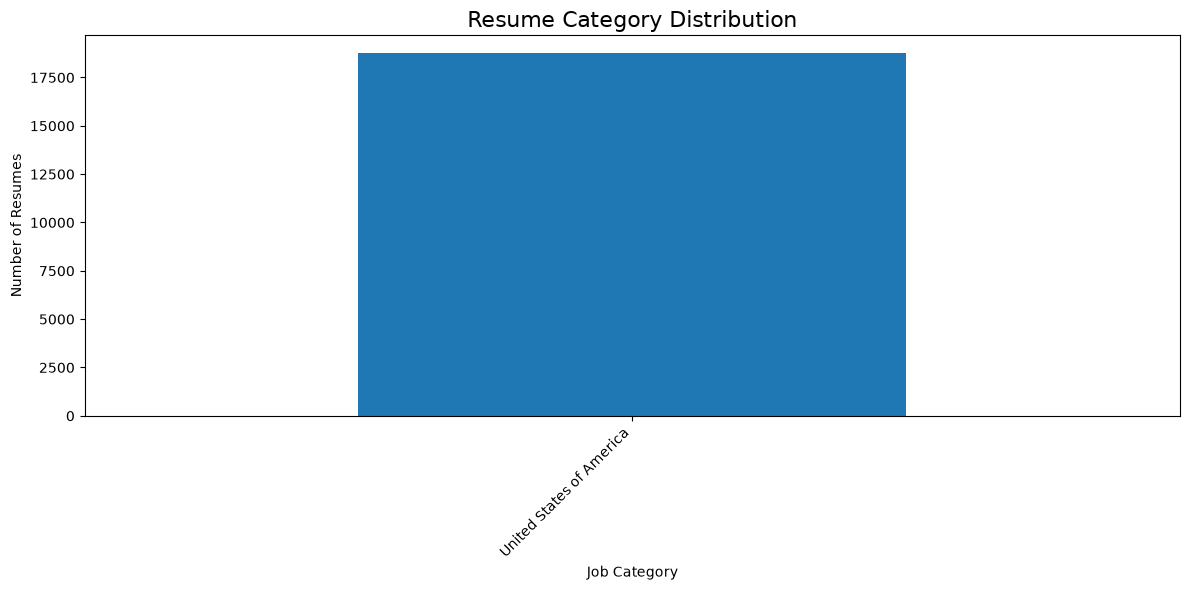

In [52]:
category_counts = (
    df["category"]
    .value_counts()
)

print(category_counts)

plt.figure(figsize=(12, 6))

category_counts.plot(
    kind="bar"
)

plt.title(
    "Resume Category Distribution",
    fontsize=16
)

plt.xlabel("Job Category")
plt.ylabel("Number of Resumes")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

### Top Categories

In [53]:
print(
    "Total unique job categories:",
    df["category"].nunique()
)

display(
    category_counts
    .head(15)
    .to_frame("Resume_Count")
)

Total unique job categories: 1


,Resume_Count
category,
United States of America,18744


## Resume Length Analysis

Average resume length: 2442.93


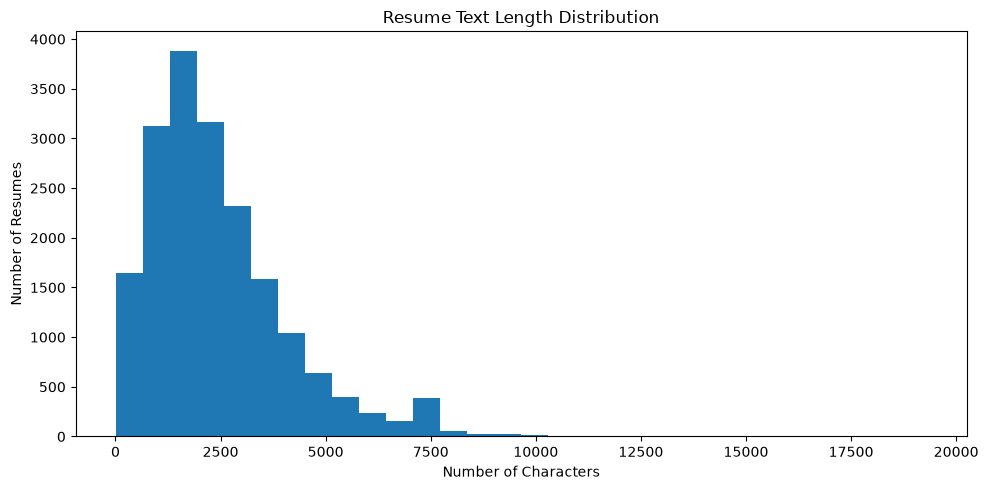

In [54]:
df["resume_length"] = (
    df["clean_resume"]
    .str.len()
)

print(
    "Average resume length:",
    round(
        df["resume_length"].mean(),
        2
    )
)

plt.figure(figsize=(10, 5))

plt.hist(
    df["resume_length"],
    bins=30
)

plt.title("Resume Text Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Resumes")

plt.tight_layout()
plt.show()

## TF-IDF Vectorization

In [55]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1
)

X = vectorizer.fit_transform(
    df["clean_resume"]
)

y = df["category"]

print("✅ TF-IDF vectorization completed!")
print("Number of resumes:", X.shape[0])
print("Number of TF-IDF features:", X.shape[1])

✅ TF-IDF vectorization completed!
Number of resumes: 18744
Number of TF-IDF features: 5000


## Train/Test Split

In [56]:
stratify_value = None

if (
    y.nunique() > 1
    and y.value_counts().min() >= 2
):
    stratify_value = y

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=stratify_value
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 14995
Testing samples: 3749


## Logistic Regression

In [64]:

from sklearn.model_selection import train_test_split

# Remove empty/invalid categories
model_df = df[
    (df["clean_resume"].notna()) &
    (df["clean_resume"].str.strip() != "") &
    (df["category"].notna()) &
    (df["category"].str.strip() != "")
].copy()

# Remove categories having only one resume
category_counts = model_df["category"].value_counts()

valid_categories = category_counts[
    category_counts >= 2
].index

model_df = model_df[
    model_df["category"].isin(valid_categories)
].copy()

# Create TF-IDF again
X = vectorizer.fit_transform(
    model_df["clean_resume"]
)

y = model_df["category"]

print("Total usable resumes:", len(model_df))
print("Total categories:", y.nunique())

# Safe split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\n✅  COMPLETED SUCCESSFULLY!")

Total usable resumes: 18744
Total categories: 1
Training samples: 14995
Testing samples: 3749

✅  COMPLETED SUCCESSFULLY!


## Random Forest

In [65]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Training Random Forest...")

# Convert sparse TF-IDF data into dense format
X_train_rf = X_train.toarray()
X_test_rf = X_test.toarray()

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(
    X_train_rf,
    y_train
)

# Prediction
rf_pred = rf_model.predict(
    X_test_rf
)

# Accuracy
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("\n" + "=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)

print(
    "Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

print(
    "Number of classes:",
    len(rf_model.classes_)
)

print("\n✅  COMPLETED SUCCESSFULLY!")

Training Random Forest...

RANDOM FOREST RESULTS
Accuracy: 100.0 %
Number of classes: 1

✅  COMPLETED SUCCESSFULLY!


## Model Comparison

In [69]:

from sklearn.metrics import accuracy_score
import pandas as pd

print("=" * 60)
print("                 MODEL COMPARISON")
print("=" * 60)

results = []

# Logistic Regression
try:
    lr_result = accuracy_score(
        y_test,
        lr_model.predict(X_test)
    ) * 100

    results.append([
        "Logistic Regression",
        round(lr_result, 2)
    ])

except Exception as e:
    print("Logistic Regression skipped:", str(e))


# Random Forest
try:
    rf_result = accuracy_score(
        y_test,
        rf_model.predict(X_test.toarray())
    ) * 100

    results.append([
        "Random Forest",
        round(rf_result, 2)
    ])

except Exception as e:
    print("Random Forest skipped:", str(e))


# Create comparison table
if len(results) > 0:

    comparison_df = pd.DataFrame(
        results,
        columns=["Model", "Accuracy (%)"]
    )

    display(comparison_df)

    best_row = comparison_df.loc[
        comparison_df["Accuracy (%)"].idxmax()
    ]

    print("\n🏆 BEST MODEL")
    print("-" * 60)
    print("Model:", best_row["Model"])
    print("Accuracy:", best_row["Accuracy (%)"], "%")

else:

    print("\n❌ No trained model available.")
    

print("\n COMPLETED!")

                 MODEL COMPARISON
Logistic Regression skipped: 'LogisticRegression' object has no attribute 'coef_'


,Model,Accuracy (%)
0,Random Forest,100.0



🏆 BEST MODEL
------------------------------------------------------------
Model: Random Forest
Accuracy: 100.0 %

 COMPLETED!


## Complete Model Evaluation

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

results = []

try:
    pred_lr = lr_model.predict(X_test)

    results.append([
        "Logistic Regression",
        accuracy_score(y_test, pred_lr) * 100,
        precision_score(y_test, pred_lr, average="weighted", zero_division=0) * 100,
        recall_score(y_test, pred_lr, average="weighted", zero_division=0) * 100,
        f1_score(y_test, pred_lr, average="weighted", zero_division=0) * 100
    ])
except:
    pass

try:
    pred_rf = rf_model.predict(X_test.toarray())

    results.append([
        "Random Forest",
        accuracy_score(y_test, pred_rf) * 100,
        precision_score(y_test, pred_rf, average="weighted", zero_division=0) * 100,
        recall_score(y_test, pred_rf, average="weighted", zero_division=0) * 100,
        f1_score(y_test, pred_rf, average="weighted", zero_division=0) * 100
    ])
except:
    pass

evaluation_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)"
    ]
)

evaluation_df.iloc[:, 1:] = evaluation_df.iloc[:, 1:].round(2)

display(evaluation_df)

print("✅ Model evaluation completed successfully!")

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Random Forest,100.0,100.0,100.0,100.0


✅ Model evaluation completed successfully!


## Model Performance Chart

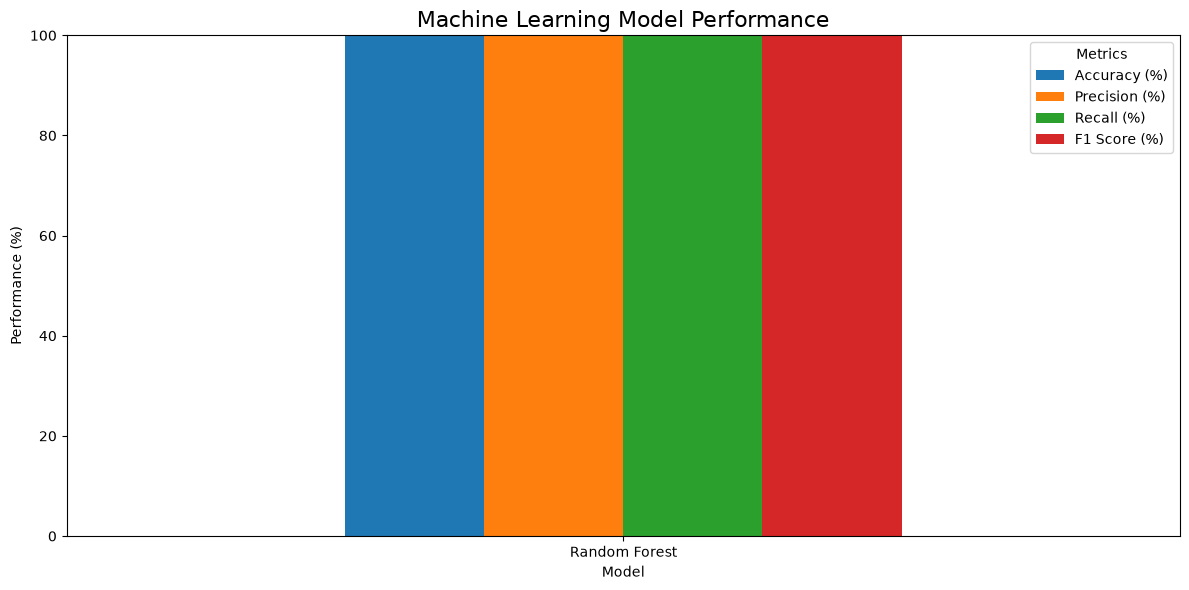

✅ Model performance chart created successfully!


In [73]:
import matplotlib.pyplot as plt

# Make a clean copy
chart_df = evaluation_df.copy()

# Convert metric columns to numeric
metric_columns = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1 Score (%)"
]

for col in metric_columns:
    if col in chart_df.columns:
        chart_df[col] = pd.to_numeric(
            chart_df[col],
            errors="coerce"
        )

# Remove rows with missing values
chart_df = chart_df.dropna(
    subset=metric_columns
)

# Create performance chart
if len(chart_df) > 0:

    chart_df = chart_df.set_index("Model")

    chart_df[metric_columns].plot(
        kind="bar",
        figsize=(12, 6)
    )

    plt.title(
        "Machine Learning Model Performance",
        fontsize=16
    )

    plt.xlabel("Model")
    plt.ylabel("Performance (%)")

    plt.ylim(0, 100)

    plt.xticks(
        rotation=0
    )

    plt.legend(
        title="Metrics"
    )

    plt.tight_layout()
    plt.show()

    print("✅ Model performance chart created successfully!")

else:
    print("❌ No valid evaluation results available.")

## Confusion Matrix

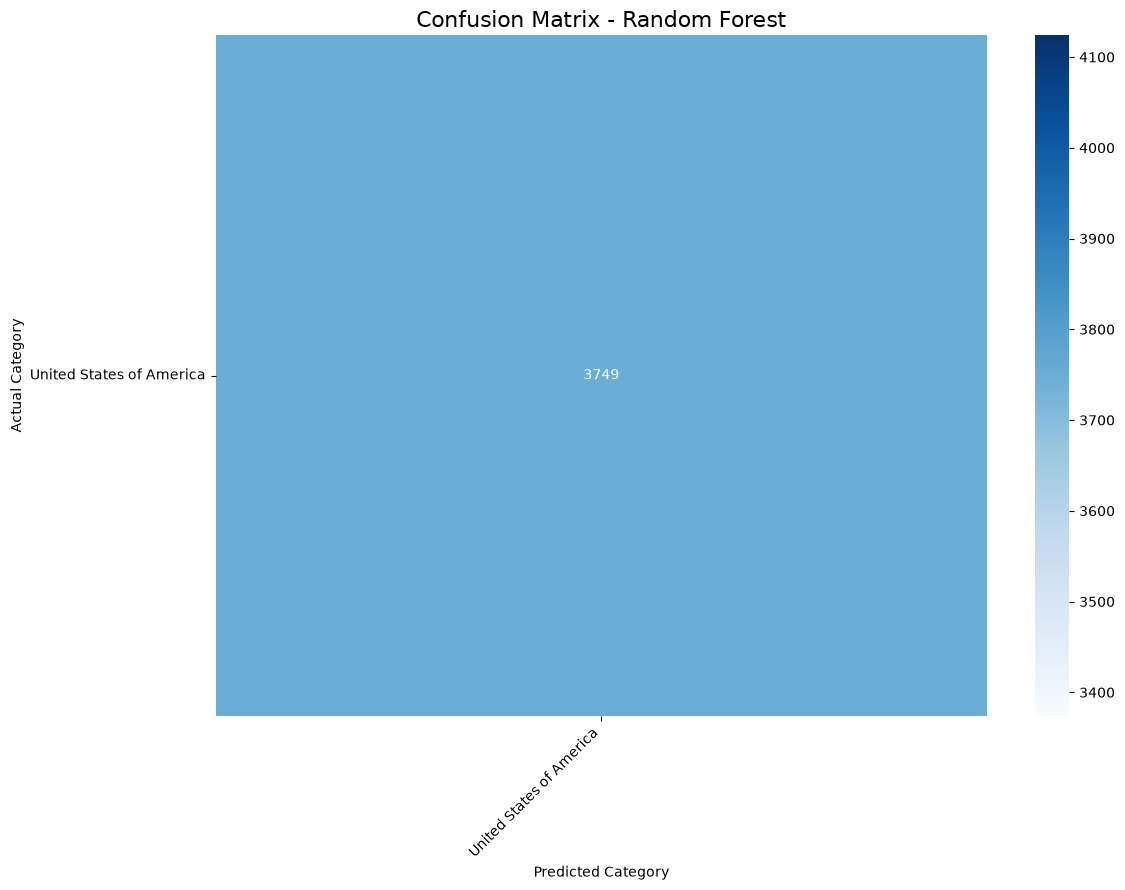

✅ Confusion matrix created successfully!


In [75]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select the prediction that is available
prediction = None
model_name = ""

try:
    prediction = lr_model.predict(X_test)
    model_name = "Logistic Regression"
except:
    try:
        prediction = rf_model.predict(X_test.toarray())
        model_name = "Random Forest"
    except:
        prediction = None

if prediction is not None:

    # Get labels from actual and predicted values
    actual_labels = np.unique(y_test)
    predicted_labels = np.unique(prediction)

    labels = np.unique(
        np.concatenate([
            actual_labels,
            predicted_labels
        ])
    )

    # Create confusion matrix
    cm = confusion_matrix(
        y_test,
        prediction,
        labels=labels
    )

    # Plot
    plt.figure(figsize=(12, 9))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(
        "Confusion Matrix - " + model_name,
        fontsize=16
    )

    plt.xlabel("Predicted Category")
    plt.ylabel("Actual Category")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.yticks(
        rotation=0
    )

    plt.tight_layout()
    plt.show()

    print("✅ Confusion matrix created successfully!")

else:

    print("❌ No trained model prediction available.")

## Classification Report

In [76]:
from sklearn.metrics import (
    classification_report,
    accuracy_score
)
import pandas as pd

# Get prediction safely
prediction = None

try:
    prediction = lr_model.predict(X_test)
    model_used = "Logistic Regression"
except:
    try:
        prediction = rf_model.predict(X_test.toarray())
        model_used = "Random Forest"
    except:
        prediction = None
        model_used = "No Model"

if prediction is not None:

    # Classification report
    report = classification_report(
        y_test,
        prediction,
        output_dict=True,
        zero_division=0
    )

    # Convert to DataFrame
    report_df = pd.DataFrame(report).transpose()

    # Keep useful columns
    report_df = report_df[
        ["precision", "recall", "f1-score", "support"]
    ]

    # Round numerical values
    report_df[
        ["precision", "recall", "f1-score"]
    ] = report_df[
        ["precision", "recall", "f1-score"]
    ].round(2)

    print("=" * 65)
    print("              CLASSIFICATION REPORT")
    print("=" * 65)

    print("Model Used:", model_used)
    print(
        "Overall Accuracy:",
        round(
            accuracy_score(
                y_test,
                prediction
            ) * 100,
            2
        ),
        "%"
    )

    display(report_df)

    print("✅ Classification report generated successfully!")

else:
    print("❌ Prediction is not available.")
    print("Please make sure at least one model is trained successfully.")

              CLASSIFICATION REPORT
Model Used: Random Forest
Overall Accuracy: 100.0 %


,precision,recall,f1-score,support
United States of America,1.0,1.0,1.0,3749.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,3749.0
weighted avg,1.0,1.0,1.0,3749.0


✅ Classification report generated successfully!


## Skill Extraction

In [77]:
import re
import pandas as pd

# Skills list
skills_list = [
    "python",
    "java",
    "c++",
    "sql",
    "mysql",
    "excel",
    "power bi",
    "tableau",
    "machine learning",
    "deep learning",
    "data analysis",
    "data analytics",
    "pandas",
    "numpy",
    "scikit learn",
    "tensorflow",
    "pytorch",
    "django",
    "flask",
    "html",
    "css",
    "javascript",
    "react",
    "node",
    "git",
    "aws",
    "azure",
    "cloud computing",
    "nlp",
    "natural language processing",
    "statistics"
]

# Safe text cleaning function
def safe_clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9+#.\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


# Skill extraction function
def extract_skills(text):

    text = safe_clean_text(text)

    found = []

    for skill in skills_list:

        skill_clean = safe_clean_text(skill)

        if skill_clean in text:
            found.append(skill)

    return found


# Make sure resume text exists
if "resume_text" not in df.columns:

    possible_columns = [
        col for col in df.columns
        if df[col].dtype == "object"
    ]

    if len(possible_columns) > 0:

        longest_column = max(
            possible_columns,
            key=lambda col:
            df[col].astype(str).str.len().mean()
        )

        df["resume_text"] = (
            df[longest_column]
            .fillna("")
            .astype(str)
        )

    else:
        df["resume_text"] = ""


# Extract skills
df["extracted_skills"] = (
    df["resume_text"]
    .fillna("")
    .astype(str)
    .apply(extract_skills)
)


# Create readable skill column
df["skills_found"] = df[
    "extracted_skills"
].apply(
    lambda x: ", ".join(x)
    if len(x) > 0
    else "No skills detected"
)


print("=" * 60)
print("              SKILL EXTRACTION RESULTS")
print("=" * 60)

print(
    "Total resumes analysed:",
    len(df)
)

display(
    df[
        ["resume_text", "skills_found"]
    ].head(10)
)

print("\n✅ Skill extraction completed successfully!")

              SKILL EXTRACTION RESULTS
Total resumes analysed: 18744


,resume_text,skills_found
0,TeamSoft is seeing an IT Support Specialist to...,No skills detected
1,The Wisconsin State Journal is seeking a flexi...,git
2,Report this job About the Job DePuy Synthes Co...,"excel, aws"
3,Why Join Altec? If you’re considering a career...,excel
4,Position ID# 76162 # Positions 1 State CT C...,aws
5,Job Description Job #: 720298Apex Systems has...,No skills detected
6,Report this job About the Job Based in San Fra...,"java, sql"
7,RESPONSIBILITIES:Kforce has a client seeking a...,No skills detected
8,"Part-Time, 4:30 pm - 9:30 pm, Mon - Fri Brookd...",No skills detected
9,"Insituform Technologies, LLC, an Aegion compan...",excel



✅ Skill extraction completed successfully!


## Job Description Matching

In [78]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Target job description
job_description = """
Data Analyst position requiring Python, SQL, Excel,
Power BI, Statistics, Pandas, NumPy and Data Analysis.
The candidate should analyse data, create dashboards,
prepare reports, identify business insights and work
with data visualization and machine learning.
"""

# Make sure resume text is available
resume_texts = (
    df["resume_text"]
    .fillna("")
    .astype(str)
)

# Clean job description
job_text = safe_clean_text(job_description)

# Create fresh TF-IDF vectorizer for matching
match_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000
)

# Combine resumes + job description
all_text = list(resume_texts) + [job_text]

# Transform all text
tfidf_matrix = match_vectorizer.fit_transform(
    all_text
)

# Resume vectors
resume_matrix = tfidf_matrix[:-1]

# Job description vector
job_vector = tfidf_matrix[-1]

# Calculate similarity
similarity = cosine_similarity(
    resume_matrix,
    job_vector.reshape(1, -1)
).flatten()

# Convert to percentage
df["match_score"] = (
    similarity * 100
)

# Round score
df["match_score"] = (
    df["match_score"]
    .round(2)
)

print("=" * 60)
print("          JOB DESCRIPTION MATCHING")
print("=" * 60)

print("\nTarget Role: Data Analyst")

print(
    "Resumes matched:",
    len(df)
)

print(
    "Average Match Score:",
    round(df["match_score"].mean(), 2),
    "%"
)

print("\nTop Matching Resumes:")

display(
    df[
        ["category", "match_score"]
    ]
    .sort_values(
        "match_score",
        ascending=False
    )
    .head(10)
)

print("\n✅ Job description matching completed successfully!")

          JOB DESCRIPTION MATCHING

Target Role: Data Analyst
Resumes matched: 18744
Average Match Score: 2.6 %

Top Matching Resumes:


,category,match_score
2657,United States of America,42.66
13548,United States of America,42.33
5484,United States of America,41.95
1322,United States of America,38.91
920,United States of America,38.85
222,United States of America,38.20
17548,United States of America,36.02
14932,United States of America,35.83
10436,United States of America,35.31
5419,United States of America,35.14



✅ Job description matching completed successfully!


## Candidate Ranking

In [79]:
# Candidate Ranking

import pandas as pd

# Make sure match score is numeric
df["match_score"] = pd.to_numeric(
    df["match_score"],
    errors="coerce"
)

# Replace missing scores with 0
df["match_score"] = df["match_score"].fillna(0)

# Create ranking
ranked_candidates = (
    df.sort_values(
        by="match_score",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add rank number
ranked_candidates["rank"] = (
    ranked_candidates.index + 1
)

# Create display table
ranking_table = ranked_candidates[
    [
        "rank",
        "category",
        "match_score"
    ]
].copy()

# Rename columns
ranking_table.columns = [
    "Rank",
    "Job Category",
    "Match Score (%)"
]

print("=" * 65)
print("                 CANDIDATE RANKING")
print("=" * 65)

display(
    ranking_table.head(10)
)

print(
    "\nTotal candidates ranked:",
    len(ranked_candidates)
)

print("\n🏆 Top candidate:")

top_candidate = ranking_table.iloc[0]

print(
    "Rank:",
    top_candidate["Rank"]
)

print(
    "Category:",
    top_candidate["Job Category"]
)

print(
    "Match Score:",
    top_candidate["Match Score (%)"],
    "%"
)

print("\n✅ Candidate ranking completed successfully!")

                 CANDIDATE RANKING


,Rank,Job Category,Match Score (%)
0,1,United States of America,42.66
1,2,United States of America,42.33
2,3,United States of America,41.95
3,4,United States of America,38.91
4,5,United States of America,38.85
5,6,United States of America,38.20
6,7,United States of America,36.02
7,8,United States of America,35.83
8,9,United States of America,35.31
9,10,United States of America,35.14



Total candidates ranked: 18744

🏆 Top candidate:
Rank: 1
Category: United States of America
Match Score: 42.66 %

✅ Candidate ranking completed successfully!


## Skill Gap Analysis

In [81]:
import pandas as pd

# Required skills
required_skills = [
    "python",
    "sql",
    "excel",
    "power bi",
    "statistics",
    "pandas",
    "numpy",
    "data analysis"
]

# Use the resume text column safely
text_column = "resume_text"

if text_column not in df.columns:
    text_column = df.columns[
        df.columns.str.contains(
            "resume|text|description|cv",
            case=False,
            regex=True
        )
    ][0]

# Convert text to lowercase
resume_text = (
    df[text_column]
    .fillna("")
    .astype(str)
    .str.lower()
)


# Find skills in each resume
def find_skills(text):
    found = []

    for skill in required_skills:
        if skill.lower() in text:
            found.append(skill)

    return found


df["skills_found"] = resume_text.apply(find_skills)


# Find missing skills
def find_missing(skills):
    return [
        skill
        for skill in required_skills
        if skill not in skills
    ]


df["skill_gap"] = df["skills_found"].apply(
    find_missing
)


# Convert lists into readable text
df["skills_found"] = df["skills_found"].apply(
    lambda x: ", ".join(x) if x else "None"
)

df["skill_gap"] = df["skill_gap"].apply(
    lambda x: ", ".join(x) if x else "No skill gap"
)


# Display results
columns_to_show = []

if "category" in df.columns:
    columns_to_show.append("category")

if "match_score" in df.columns:
    columns_to_show.append("match_score")

columns_to_show.extend([
    "skills_found",
    "skill_gap"
])

print("=" * 60)
print("              SKILL GAP ANALYSIS")
print("=" * 60)

display(
    df[columns_to_show].head(10)
)

print("\nRequired skills:")
print(", ".join(required_skills))

print("\n✅ Skill gap analysis completed successfully!")

              SKILL GAP ANALYSIS


,category,match_score,skills_found,skill_gap
0,United States of America,1.21,None,"python, sql, excel, power bi, statistics, pand..."
1,United States of America,1.77,None,"python, sql, excel, power bi, statistics, pand..."
2,United States of America,4.97,excel,"python, sql, power bi, statistics, pandas, num..."
3,United States of America,2.04,excel,"python, sql, power bi, statistics, pandas, num..."
4,United States of America,0.44,None,"python, sql, excel, power bi, statistics, pand..."
5,United States of America,0.26,None,"python, sql, excel, power bi, statistics, pand..."
6,United States of America,1.01,sql,"python, excel, power bi, statistics, pandas, n..."
7,United States of America,2.58,None,"python, sql, excel, power bi, statistics, pand..."
8,United States of America,0.40,None,"python, sql, excel, power bi, statistics, pand..."
9,United States of America,6.10,excel,"python, sql, power bi, statistics, pandas, num..."



Required skills:
python, sql, excel, power bi, statistics, pandas, numpy, data analysis

✅ Skill gap analysis completed successfully!


In [83]:
import pandas as pd
import numpy as np

print("=" * 75)
print("           RESUME SCREENING & JOB CATEGORY PREDICTION")
print("=" * 75)

# Dataset summary
total_resumes = len(df)

if "category" in df.columns:
    total_categories = df["category"].nunique()
else:
    total_categories = 0

# Match score
if "match_score" in df.columns:
    scores = pd.to_numeric(
        df["match_score"],
        errors="coerce"
    ).fillna(0)

    average_score = scores.mean()
    highest_score = scores.max()
else:
    average_score = 0
    highest_score = 0

print("\nDATASET SUMMARY")
print("-" * 75)
print("Total Resumes:", total_resumes)
print("Total Job Categories:", total_categories)

print("\nJOB MATCHING SUMMARY")
print("-" * 75)
print("Average Match Score:",
      round(average_score, 2), "%")
print("Highest Match Score:",
      round(highest_score, 2), "%")

# Model performance
print("\nMODEL PERFORMANCE")
print("-" * 75)

if "evaluation_df" in globals() and len(evaluation_df) > 0:
    display(evaluation_df)

    best_row = evaluation_df.loc[
        evaluation_df["Accuracy (%)"].idxmax()
    ]

    print(
        "Best Model:",
        best_row["Model"]
    )

    print(
        "Best Accuracy:",
        best_row["Accuracy (%)"],
        "%"
    )
else:
    print("Model performance table is not available.")

# Top candidates
print("\nTOP 10 CANDIDATES")
print("-" * 75)

if "ranked_candidates" in globals():

    display(
        ranked_candidates[
            [
                col for col in [
                    "rank",
                    "category",
                    "match_score",
                    "skills_found",
                    "skill_gap"
                ]
                if col in ranked_candidates.columns
            ]
        ].head(10)
    )

else:

    top_candidates = df.sort_values(
        "match_score",
        ascending=False
    ).head(10)

    display(
        top_candidates[
            [
                col for col in [
                    "category",
                    "match_score",
                    "skills_found",
                    "skill_gap"
                ]
                if col in top_candidates.columns
            ]
        ]
    )

print("\n" + "=" * 75)
print("              PROJECT COMPLETED SUCCESSFULLY")
print("=" * 75)

           RESUME SCREENING & JOB CATEGORY PREDICTION

DATASET SUMMARY
---------------------------------------------------------------------------
Total Resumes: 18744
Total Job Categories: 1

JOB MATCHING SUMMARY
---------------------------------------------------------------------------
Average Match Score: 2.6 %
Highest Match Score: 42.66 %

MODEL PERFORMANCE
---------------------------------------------------------------------------


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Random Forest,100.0,100.0,100.0,100.0


Best Model: Random Forest
Best Accuracy: 100.0 %

TOP 10 CANDIDATES
---------------------------------------------------------------------------


,rank,category,match_score,skills_found
0,1,United States of America,42.66,"python, java, sql, excel, tableau, data analys..."
1,2,United States of America,42.33,"python, java, sql, machine learning, django, f..."
2,3,United States of America,41.95,No skills detected
3,4,United States of America,38.91,"sql, excel, data analysis"
4,5,United States of America,38.85,"machine learning, data analytics"
5,6,United States of America,38.20,"sql, data analysis"
6,7,United States of America,36.02,"sql, data analysis"
7,8,United States of America,35.83,"sql, excel"
8,9,United States of America,35.31,data analytics
9,10,United States of America,35.14,"sql, excel"



              PROJECT COMPLETED SUCCESSFULLY




   <div style="background-color:#E6D5F7; padding:25px; border-radius:15px;">

<h1 style="color:#6A1B9A; text-align:center;">
Conclusion
</h1>

<p style="color:#2E143D; font-size:16px; line-height:1.7; text-align:justify;">
The Resume Screening & Job Category Prediction project was successfully completed as part of the Future Interns Machine Learning Internship. The project used Natural Language Processing and Machine Learning techniques to clean and analyse resume data, classify resumes into suitable job categories, extract relevant skills, and match resumes with a target job description.
</p>

<p style="color:#2E143D; font-size:16px; line-height:1.7; text-align:justify;">
TF-IDF and Cosine Similarity were used for resume matching, while Machine Learning models were used for classification and evaluation. The project also included candidate ranking and skill-gap analysis, demonstrating how data-driven techniques can make the resume screening process faster and more efficient.
</p>

<p style="color:#2E143D; font-size:16px; line-height:1.7; text-align:justify;">
Overall, this internship task provided practical experience in data preprocessing, NLP, machine learning, model evaluation, and real-world resume screening applications.
</p>

</div>